In [1]:
# Import and run the data generator
import os

# Ensure we're in the correct directory (where data.py and config should be)
if not os.getcwd().endswith('data\\data'):
    os.chdir('c:/Users/Hp/Desktop/data/data')

from data import Data

# Initialize data generator (cleanup happens automatically during __init__)
# data_gen = Data(seed=42, simbench_code='1-LV-rural2--1-no_sw')
data_gen = Data(seed=42, simbench_code='1-LV-urban6--2-no_sw')


# Generate data (config file is automatically loaded from initialization)
print("Starting data generation...\n")

filtered_dfs, time_range = data_gen.generate_consistent_copies()
print("\n✅ Data generation complete!")
print(f"Generated {len(filtered_dfs)} datasets")


🗑️ Cleaning up existing generated files...
  Deleted: load_actual.csv
  Deleted: load_forecast_da.csv
  Deleted: load_forecast_id.csv
  Deleted: res_actual.csv
  Deleted: res_forecast_da.csv
  Deleted: res_forecast_id.csv
  Deleted: storage_actual.csv
  Deleted: storage_forecast_da.csv
  Deleted: storage_forecast_id.csv
  Deleted: prices.csv
✓ Deleted 10 files

Found config file: data_config.json
Starting data generation...

Using SimBench code from instance: '1-LV-urban6--2-no_sw'

GENERATING CONSISTENT DATA SEQUENCE
Loading Load + RES + Storage from SimBench '1-LV-urban6--2-no_sw'...
Raw Load columns (45): 45
Raw Renewables columns (5): 5
Raw Storage columns (7): 7

Converting normalized profiles to absolute MW...
  Load units: 135 individual units converted to MW
  RES units: 12 individual generators converted to MW
  Storage units: 7 individual units converted to MW
✓ Profiles converted to absolute MW values
   load sample time: '01.01.2016 00:00'
   load time parsed with format: %

In [2]:
# Display Load Actual data
print("📊 LOAD ACTUAL DATA (MW)")
print("="*80)
print(f"Shape: {filtered_dfs['load_actual'].shape}")
print(f"Columns: {len(filtered_dfs['load_actual'].columns)}")
print(f"\nFirst 5 rows:")
filtered_dfs['load_actual'].head()


📊 LOAD ACTUAL DATA (MW)
Shape: (35136, 136)
Columns: 136

First 5 rows:


,datetime,LV6.201 Load 16 [G1-B],LV6.201 Load 24 [H0-L],LV6.201 Load 36 [H0-A],LV6.201 Load 7 [H0-C],LV6.201 Load 33 [G1-B],LV6.201 Load 28 [H0-G],LV6.201 Load 37 [H0-A],LV6.201 Load 19 [H0-G],LV6.201 Load 9 [H0-L],...,LV6.201 Load 126 [Air_Semi-Parallel_2],LV6.201 Load 127 [Air_Parallel_2],LV6.201 Load 128 [Soil_Alternative_2],LV6.201 Load 129 [HLS_C_3.7],LV6.201 Load 130 [HLS_A_3.7],LV6.201 Load 131 [Soil_Alternative_2],LV6.201 Load 132 [Air_Semi-Parallel_2],LV6.201 Load 133 [HLS_B_3.7],LV6.201 Load 134 [HLS_A_11.0],LV6.201 Load 135 [HLS_C_3.7]
0,2016-01-01 00:00:00,0.000329,0.000161,0.000830,0.001162,0.000238,0.000253,0.000830,0.000337,0.000161,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016-01-01 00:15:00,0.000564,0.000060,0.000198,0.000328,0.000409,0.000478,0.000198,0.000638,0.000060,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2016-01-01 00:30:00,0.000517,0.000064,0.000619,0.000313,0.000375,0.000489,0.000619,0.000652,0.000064,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2016-01-01 00:45:00,0.000564,0.000050,0.000383,0.000320,0.000409,0.000543,0.000383,0.000724,0.000050,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2016-01-01 01:00:00,0.000329,0.000083,0.000324,0.000372,0.000238,0.000731,0.000324,0.000975,0.000083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Print load columns list (excluding datetime, sorted by unit number)
import re

def extract_unit_id(col_name):
    """Extract unit number for sorting"""
    match = re.search(r'Load\s+(\d+)', col_name)
    return int(match.group(1)) if match else 0

sorted([col for col in filtered_dfs['load_actual'].columns if col != 'datetime'], key=extract_unit_id)


['LV6.201 Load 1 [H0-A]',
 'LV6.201 Load 2 [G4-A]',
 'LV6.201 Load 3 [H0-A]',
 'LV6.201 Load 4 [G6-A]',
 'LV6.201 Load 5 [H0-B]',
 'LV6.201 Load 6 [H0-A]',
 'LV6.201 Load 7 [H0-C]',
 'LV6.201 Load 8 [H0-L]',
 'LV6.201 Load 9 [H0-L]',
 'LV6.201 Load 10 [H0-B]',
 'LV6.201 Load 11 [H0-A]',
 'LV6.201 Load 12 [H0-B]',
 'LV6.201 Load 13 [H0-C]',
 'LV6.201 Load 14 [H0-C]',
 'LV6.201 Load 15 [H0-B]',
 'LV6.201 Load 16 [G1-B]',
 'LV6.201 Load 17 [G6-A]',
 'LV6.201 Load 18 [G4-A]',
 'LV6.201 Load 19 [H0-G]',
 'LV6.201 Load 20 [H0-A]',
 'LV6.201 Load 21 [H0-L]',
 'LV6.201 Load 22 [H0-G]',
 'LV6.201 Load 23 [G1-A]',
 'LV6.201 Load 24 [H0-L]',
 'LV6.201 Load 25 [H0-B]',
 'LV6.201 Load 26 [H0-L]',
 'LV6.201 Load 27 [H0-A]',
 'LV6.201 Load 28 [H0-G]',
 'LV6.201 Load 29 [H0-L]',
 'LV6.201 Load 30 [H0-A]',
 'LV6.201 Load 31 [H0-C]',
 'LV6.201 Load 32 [H0-C]',
 'LV6.201 Load 33 [G1-B]',
 'LV6.201 Load 34 [H0-B]',
 'LV6.201 Load 35 [H0-B]',
 'LV6.201 Load 36 [H0-A]',
 'LV6.201 Load 37 [H0-A]',
 'LV6.201 

In [4]:
# Print RES columns list (excluding datetime, sorted by unit number)
import re

def extract_unit_id(col_name):
    """Extract unit number for sorting"""
    match = re.search(r'SGen\s+(\d+)', col_name)
    return int(match.group(1)) if match else 0

sorted([col for col in filtered_dfs['res_actual'].columns if col != 'datetime'], key=extract_unit_id)


['LV6.201 SGen 1 [PV8]',
 'LV6.201 SGen 2 [PV2]',
 'LV6.201 SGen 3 [PV6]',
 'LV6.201 SGen 4 [PV5]',
 'LV6.201 SGen 5 [PV8]',
 'LV6.201 SGen 6 [PV5]',
 'LV6.201 SGen 7 [PV8]',
 'LV6.201 SGen 8 [PV2]',
 'LV6.201 SGen 9 [PV8]',
 'LV6.201 SGen 10 [PV8]',
 'LV6.201 SGen 11 [PV8]',
 'LV6.201 SGen 12 [PV8]']

In [5]:
# Print storage columns list (excluding datetime, sorted by unit number)
import re

def extract_unit_id(col_name):
    """Extract unit number for sorting"""
    match = re.search(r'Storage\s+(\d+)', col_name)
    return int(match.group(1)) if match else 0

sorted([col for col in filtered_dfs['storage_actual'].columns if col != 'datetime'], key=extract_unit_id)


['LV6.201 Storage 1 [Storage_PV5_H0-B]',
 'LV6.201 Storage 2 [Storage_PV2_H0-A]',
 'LV6.201 Storage 3 [Storage_PV8_H0-B]',
 'LV6.201 Storage 4 [Storage_PV8_H0-L]',
 'LV6.201 Storage 5 [Storage_PV8_H0-L]',
 'LV6.201 Storage 6 [Storage_PV6_H0-B]',
 'LV6.201 Storage 7 [Storage_PV8_H0-C]']

In [6]:
# Display all units grouped by Bus, Type, and ordered by unit number
import re
import pandas as pd


def parse_column_name(col_name):
    """Parse column name to extract bus, type, and unit number"""
    match = re.match(r'LV\d+\.(\d+)\s+(Load|SGen|Storage)\s+(\d+)', col_name)
    if match:
        bus_num = int(match.group(1))
        unit_type = match.group(2)
        unit_num = int(match.group(3))
        return bus_num, unit_type, unit_num, col_name
    return None, None, None, None


def extract_units_from_dataframe(df, unit_type_name):
    """Extract units from a dataframe and return as DataFrame ordered by unit number"""
    units_data = []
    for col in df.columns:
        if col != 'datetime':
            bus, utype, unum, fullname = parse_column_name(col)
            if bus is not None:
                units_data.append({
                    'bus': bus,
                    'unit_type': unit_type_name,
                    'unit_number': unum,
                    'full_name': fullname
                })
    
    units_df = pd.DataFrame(units_data)
    if not units_df.empty:
        units_df = units_df.sort_values('unit_number').reset_index(drop=True)
    return units_df


# Step 1: Create dataframes for loads, res, and storage (ordered by unit number)
loads_df = extract_units_from_dataframe(filtered_dfs['load_actual'], 'Load')
res_df = extract_units_from_dataframe(filtered_dfs['res_actual'], 'SGen')
storages_df = extract_units_from_dataframe(filtered_dfs['storage_actual'], 'Storage')

# Step 2: Combine all units and group by bus and unit type, ordered by unit number
all_units_df = pd.concat([loads_df, res_df, storages_df], ignore_index=True)
all_units_df = all_units_df.sort_values(['bus', 'unit_type', 'unit_number']).reset_index(drop=True)

# Step 3: Display with proper cascading structure
print("📊 ALL UNITS GROUPED BY BUS AND TYPE")
print("="*80)
print(f"Total units: {len(all_units_df)}\n")

current_bus = None
current_type = None

for idx, row in all_units_df.iterrows():
    # New bus
    if row['bus'] != current_bus:
        current_bus = row['bus']
        current_type = None
        print(f"\n🔹 BUS {current_bus}")
    
    # New unit type within the same bus
    if row['unit_type'] != current_type:
        current_type = row['unit_type']
        print(f"   ├── {current_type}")
    
    # Display unit (check if it's the last unit in this type for proper tree formatting)
    next_idx = idx + 1
    is_last_in_type = (next_idx >= len(all_units_df) or 
                       all_units_df.iloc[next_idx]['bus'] != current_bus or 
                       all_units_df.iloc[next_idx]['unit_type'] != current_type)
    
    if is_last_in_type:
        print(f"   │   └── Unit {row['unit_number']}: {row['full_name']}")
    else:
        print(f"   │   ├── Unit {row['unit_number']}: {row['full_name']}")

print("\n" + "="*80)

📊 ALL UNITS GROUPED BY BUS AND TYPE
Total units: 154


🔹 BUS 201
   ├── Load
   │   ├── Unit 1: LV6.201 Load 1 [H0-A]
   │   ├── Unit 2: LV6.201 Load 2 [G4-A]
   │   ├── Unit 3: LV6.201 Load 3 [H0-A]
   │   ├── Unit 4: LV6.201 Load 4 [G6-A]
   │   ├── Unit 5: LV6.201 Load 5 [H0-B]
   │   ├── Unit 6: LV6.201 Load 6 [H0-A]
   │   ├── Unit 7: LV6.201 Load 7 [H0-C]
   │   ├── Unit 8: LV6.201 Load 8 [H0-L]
   │   ├── Unit 9: LV6.201 Load 9 [H0-L]
   │   ├── Unit 10: LV6.201 Load 10 [H0-B]
   │   ├── Unit 11: LV6.201 Load 11 [H0-A]
   │   ├── Unit 12: LV6.201 Load 12 [H0-B]
   │   ├── Unit 13: LV6.201 Load 13 [H0-C]
   │   ├── Unit 14: LV6.201 Load 14 [H0-C]
   │   ├── Unit 15: LV6.201 Load 15 [H0-B]
   │   ├── Unit 16: LV6.201 Load 16 [G1-B]
   │   ├── Unit 17: LV6.201 Load 17 [G6-A]
   │   ├── Unit 18: LV6.201 Load 18 [G4-A]
   │   ├── Unit 19: LV6.201 Load 19 [H0-G]
   │   ├── Unit 20: LV6.201 Load 20 [H0-A]
   │   ├── Unit 21: LV6.201 Load 21 [H0-L]
   │   ├── Unit 22: LV6.201 Load 22 [H

In [7]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


all_units_df

,bus,unit_type,unit_number,full_name
0,201,Load,1,LV6.201 Load 1 [H0-A]
1,201,Load,2,LV6.201 Load 2 [G4-A]
2,201,Load,3,LV6.201 Load 3 [H0-A]
3,201,Load,4,LV6.201 Load 4 [G6-A]
4,201,Load,5,LV6.201 Load 5 [H0-B]
5,201,Load,6,LV6.201 Load 6 [H0-A]
6,201,Load,7,LV6.201 Load 7 [H0-C]
7,201,Load,8,LV6.201 Load 8 [H0-L]
8,201,Load,9,LV6.201 Load 9 [H0-L]
9,201,Load,10,LV6.201 Load 10 [H0-B]


🔌 SIMBENCH NETWORK TOPOLOGY
Network: 1-LV-urban6--2-no_sw
Buses: 59
Lines: 57
Loads: 135
Generators (RES): 12
Storage: 7
Transformers: 1




<Figure size 1600x1200 with 0 Axes>

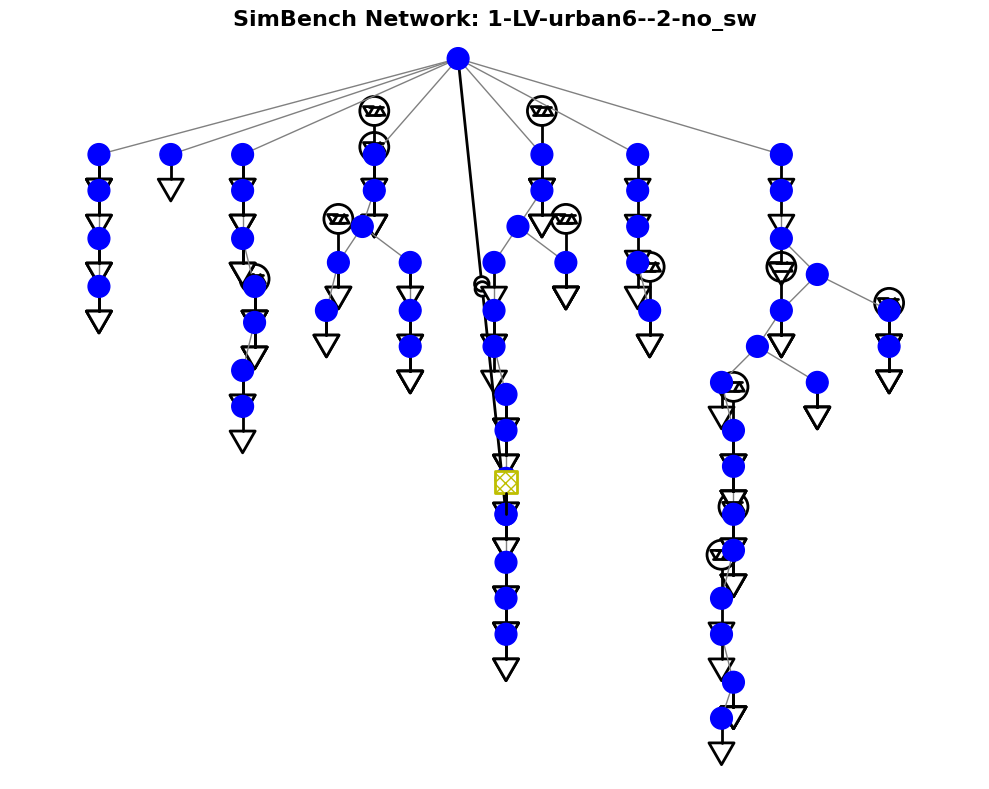

In [8]:
# Draw SimBench network topology
import sys
sys.path.append('c:/Users/Hp/Desktop/data/simbench-develop')

import simbench as sb
import pandapower.plotting as plot
import matplotlib.pyplot as plt

# Load the SimBench network
net = sb.get_simbench_net('1-LV-urban6--2-no_sw')

# Create network visualization
print("🔌 SIMBENCH NETWORK TOPOLOGY")
print("="*80)
print(f"Network: 1-LV-urban6--2-no_sw")
print(f"Buses: {len(net.bus)}")
print(f"Lines: {len(net.line)}")
print(f"Loads: {len(net.load)}")
print(f"Generators (RES): {len(net.sgen)}")
print(f"Storage: {len(net.storage)}")
print(f"Transformers: {len(net.trafo)}")
print("\n")

# Plot the network
plt.figure(figsize=(16, 12))
plot.simple_plot(net, 
                 plot_loads=True, 
                 plot_sgens=True,
                 load_size=2.0,
                 sgen_size=2.0,
                 bus_size=1.5,
                 line_width=1.0,
                 respect_switches=True,
                 show_plot=False)

plt.title('SimBench Network: 1-LV-urban6--2-no_sw', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*80)